# Progetto: Segmentazione della clientela di un azienda di servizi finanziari

## FinTech Solutions S.p.A.

### Obbiettivo principale del progetto è sviluppare un modello di segmentazione dei clienti basato sulle informazioni fornite dal dataset aziendale, contentente i dati di svariati possessori di carte di credito. Lo scopo è quello di identificare cluster specifici verso i quali indirizzare strategie di marketing mirate.

L'analisi si compone nelle seguenti fasi:
1. Caricamento e analisi esplorativa
2. Definizione funzioni
3. Preprocessing
4. Scelta del numero di cluster
5. Allenamento modello e visualizzazione cluster
6. Interpretazione dei cluster e strategie di marketing

In [ ]:
# Importazione librerie necessarie al progetto

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

## 1. Caricamento e analisi esplorativa

In [ ]:
url = "https://proai-datasets.s3.eu-west-3.amazonaws.com/credit_card_customers.csv"

df = pd.read_csv(url)

df.head()

df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


## 2. Definizione funzioni

In [ ]:
def replace_null(df, columns, method = "median"):
  """
  Sostituisce i valori nulli nelle colonne specificate.

  Parametri:
  - df: DataFrame pandas
  - columns: lista di colonne da trattare
  - method: "mediana", "media", "moda"
  """
  for col in columns:
    match method:
      case "median":
        df[col] = df[col].fillna(df[col].median())
      case "mean":
        df[col] = df[col].fillna(df[col].mean())
      case "moda":
        df[col] = df[col].fillna(df[col].mode()[0])



def elbow_method(X, k_range=(1, 10)):
  """
  Calcola e visualizza il grafico elbow per la scelta ottimale di K
  """
  inerzie={}
  for k in range (k_range[0], k_range[1]):
    kmeans = KMeans(n_clusters=k, init="k-means++", random_state=42)
    kmeans.fit(X)
    inerzie[k] = kmeans.inertia_

  plt.plot(list(inerzie.keys()), list(inerzie.values()), marker="o")
  plt.xlabel("Numero di cluster", fontsize=16)
  plt.ylabel("Somma della distanza al quadrato", fontsize=16)
  plt.show()

def silhouette_method(X, k_range=(2, 10)):
  """
  Calcola e visualizza i dati ottenuti con silhouette score per diversi valori K.
  """
  scores = {}
  for k in range(k_range[0], k_range[1]):
    kmeans = KMeans(n_clusters=k, init="k-means++", random_state=42)
    labels = kmeans.fit_predict(X)
    sil= silhouette_score(X, labels)
    scores[k]=sil
  plt.plot(list(scores.keys()), list(scores.values()), marker="o")
  plt.xlabel("Numero di cluster", fontsize=16)
  plt.ylabel("Silhouette score", fontsize=16)
  plt.show()

def cluster_interpreter(X, df, k=None):
  """
  Allena KMeans con K cluster, stampa le medie per cluster e visualizza i risultati con PCA a 2 componenti
  """
  kmeans = KMeans(n_clusters = k, init="k-means++", random_state=42)
  df["cluster"] = kmeans.fit_predict(X)
  print(df.groupby("cluster").mean())

  pca = PCA(n_components=2)
  coords = pca.fit_transform(X)
  centroids = pca.transform(kmeans.cluster_centers_)

  cluster_labels = {
        0: "Utilizzatori cash advance",
        1: "Clienti inattivi",
        2: "Spendaccioni premium",
        3: "Utilizzatori liquidità"
    }

  plt.figure(figsize=(10, 8))
  for cluster_id, label in cluster_labels.items():
      mask = df["cluster"] == cluster_id
      plt.scatter(coords[mask, 0], coords[mask, 1], label=label, alpha=0.5, s=100)

  plt.scatter(centroids[:, 0], centroids[:, 1], s=200, c="black", marker="X")
  plt.title("Visualizzazione Cluster")
  plt.legend()
  plt.show()

## 3. Preprocessing

In [ ]:
# Creazione copia del DF
df_cleaned = df.copy()

# Rimozione identificativo cliente (non utile al clustering)
df_cleaned = df_cleaned.drop("CUST_ID", axis=1)

# Scelta colonne con valori nulli
columns = ["CREDIT_LIMIT", "MINIMUM_PAYMENTS"]

# Sostituzione valori nulli con la mediana
replace_null(df_cleaned, columns)

# Verifica dati
df_cleaned.head()

df_cleaned.isnull().sum()

df_cleaned.info()

# Standardizzazione delle feature
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_cleaned)



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   BALANCE                           8950 non-null   float64
 1   BALANCE_FREQUENCY                 8950 non-null   float64
 2   PURCHASES                         8950 non-null   float64
 3   ONEOFF_PURCHASES                  8950 non-null   float64
 4   INSTALLMENTS_PURCHASES            8950 non-null   float64
 5   CASH_ADVANCE                      8950 non-null   float64
 6   PURCHASES_FREQUENCY               8950 non-null   float64
 7   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 8   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 9   CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 10  CASH_ADVANCE_TRX                  8950 non-null   int64  
 11  PURCHASES_TRX                     8950 non-null   int64  
 12  CREDIT

## 4. Scelta del numero di cluster

Per determinare il numero ottimale di cluster utilizziamo due metodi complementari:
- Elbow method: individua il punto in cui l'inerzia smette di scendere drasticamente ("gomito")
- Silhouette method: misura la qualità della separazione dei cluster <sup>1</sup>

Dalla combinazione dei due grafici si è scelto di procedere con K=4, come numero ottimale di cluster



<sup>1</sup> Il metodo non è stato oggetto del corso, ho deciso di utilizzarlo per avere uno strumento in più per valutare la qualità della segmentazione, con 17 feature l'elbow method non era di immediata interpretabilità.

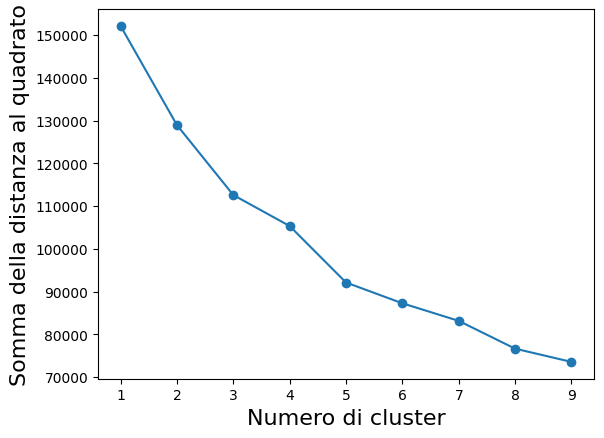

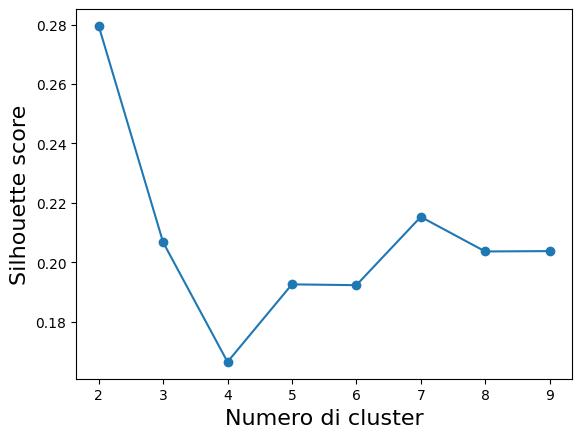

In [ ]:
elbow_method(df_scaled)


silhouette_method(df_scaled)

## 5. Allenamento modello e visualizzazione cluster

Viene allenato il modello KMeans con K=4 cluster.
Per la visualizzazione, le 17 feature originali sono state ridotte a 2 componenti principali tramite PCA<sup> 2</sup>, che permette di rappresentare i cluster in un grafico bidimensionale mantenendo il massimo dell'informazioni possibile.






<sup>2</sup> Analogamente ad metodo Silhouette, PCA non è stato oggetto del corso, ho ritenuto però che fosse utile a rendere il tutto più leggibile e interpretabile.

             BALANCE  BALANCE_FREQUENCY    PURCHASES  ONEOFF_PURCHASES  \
cluster                                                                  
0        5010.394668           0.966663   716.017789        450.235875   
1         108.430006           0.412096   350.247868        190.521089   
2        1253.817942           0.974758  2182.022178       1241.768493   
3        1495.324927           0.966467   283.482824        210.004454   

         INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
cluster                                                              
0                    265.885977   5065.974690             0.327150   
1                    160.197189    299.482324             0.320591   
2                    940.517248    234.564524             0.928413   
3                     73.794186    782.285268             0.207097   

         ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
cluster                                                      

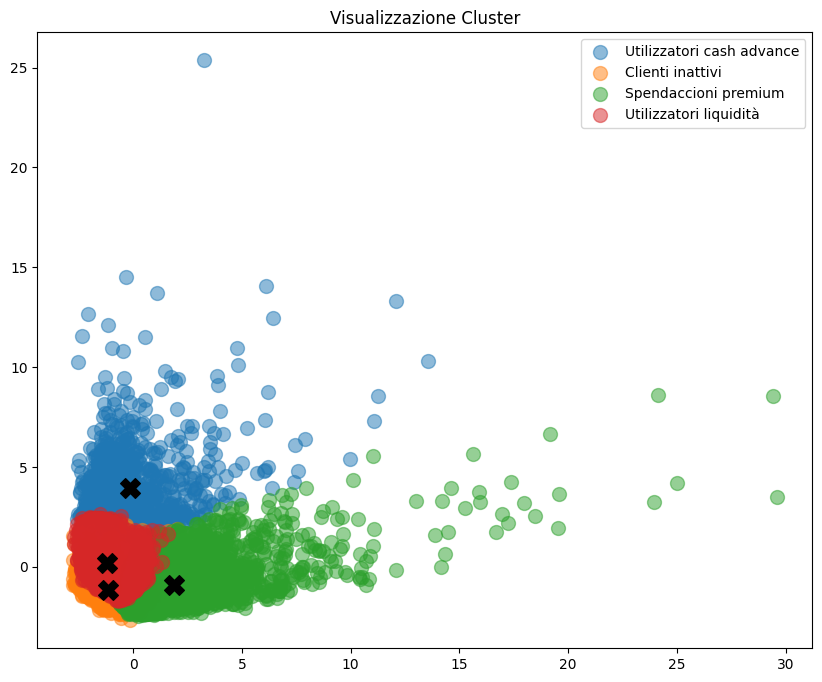

In [ ]:
cluster_interpreter(df_scaled, df_cleaned, 4)

## 6. Interpretazione dei cluster e strategie di marketing.

### Cluster 0 - Utilizzatori cash advance
**Profilo** Questo cluster è caratterizzato da clienti con un saldo residuo molto elevato (Balance) e un limite di credito alto (Credit limit: 8208). Utilizzano la carta prevalentemente per prelevare un grande ammontare di danaro piuttosto che effettuare acquisti (siano essi diretti o a rate). La frequenza di aggiornamento del saldo è alta, segnale che la carta viene utilizzata frequentemente. Raramente saldano l'intero importo mensile (PRC_FULL_PAYMENT), accumulando debito residuo su cui maturano interessi significativi.

Il profilo suggerisce si tratti di lavoratori autonomi, liberi professionisti con entrate non regolari, che utilizzano la carta come strumento principale di gestione della liquidità, ad esempio anticipare spese professionali in attesa di incassare pagamenti da parte dei clienti. Non è necessariamente un cliente in difficoltà finanziarie, ma un utilizzatore consapevole del credito come riserva di liquidità.

**Strategie di marketing** Proporre un aumento del limite di credito e prodotti finanziari dedicati alla gestione della liquidità, come linee di credito revolving con condizioni personalizzate e tassi competitivi, fidi. Potrebbe essere interessato a prodotti come il credito al consumo flessibile o soluzioni di finanziamento a breve termine (più conveniente del cash advance).

### Cluster 1 - Clienti inattivi
**Profilo** Questo cluster include clienti con saldo molto basso e limite di credito ridotto, che utilizzano la carta di credito in modo occasionale e per importi contenuti. Gli acquisti sono presenti, ma non frequenti, e prelevano raramente contanti (Cash advance). Rispetto al Cluster 0, i componenti di questo segmento sono buoni pagatori (non inteso come clienti non segnalati in centrale rischi), perchè rimborsano regolarmente parte del debito residuo.
Potrebbe trattarsi di dipendenti o studenti che hanno la carta principalmente come strumento di sicurezza o acquisti sporadici. Il basso utilizzo potrebbe dipendere da una scarsa conoscenza dei vantaggi della carta, da abitudini di pagamento in contanti o una certa prudenza finanziaria. In ogni caso il profilo è a rischio piuttosto basso e il ciente affidabile.

**Strategie di marketing** Proporre campagne di attivazione con incentivi (cashback sugli acquisti), interessi agevolati sulle rate o promozioni per categoria di spesa o per categorie specifiche (studenti, dipendenti a tempo determinato). L'obbiettivo è aumentare gradualmente l'utilizzo della carta e fidelizzare il cliente.

### Cluster 2 Spendaccioni premium
**Profilo** E' il cluster più attivo e redditizio. Questi clienti utilizzano la carta quotidianamente, con un volume di acquisti molto elevato, sia in un unica soluzione che a rate. Il numero di transazioni è il più alto tra tutti i segmenti, e la frequenza di acquisto si avvicina al massimo. Hanno un buon profilo creditizio, un limite di credito nella media e riescono a rimborsare regolarmente senza accumulare debiti eccessivi. Non ricorrono mai al cash advance, usano la carta esclusivamente per acquisti.
Questo profilo suggerisce un consumatore attivo, probabilmente con reddito stabile e abitudini di spesa consolidate. E' il cliente ideale per la banca, genera volume di transazioni, utilizza le rate e mantiene un comportamento di pagamento responsabile.

**Strategie di marketing** Aumentare il plafond della carta per incentivare acquisti di importo più elevato. Proporre programmi fedeltà (o cashback come per il cluster 1), punti premi, buoni etc. Offrire promozioni sulla rateizzazione a tasso 0 per incentivare acquisti importanti. E' il segmento su cui investire maggiormente, perchè il ritorno in termini di marketing è più alto.

### Cluster 3 Utilizzatori liquidità (e basso acquisto)
**Profilo** Questo cluster presenta caratteristiche ibride e per certi versi anomale. Il saldo si aggiorna frequentemente (Balance Frequency 0.96), segno che utilizza la carta in modo regolare, ma non per effettuare acquisti. Il ricorso al prelievo (Advance Cash) è più frequente rispetto ai cluster 1 e 2, pur essendo inferiore al segmento 0. Raramente saldano l'intero importo mensile, accumulando debito residuo.
Il profilo è di difficile interpretazione e presenta diversi campanelli d'allarme che lo rendono quello meno appetibile lato promozioni o marketing. Il fatto che i prelievi siano così frequenti e gli acquisti così ridotti suggeriscono che sia un profilo con una certa fragilità finanziaria o una gestione non ottimale del credito.

**Strategie di marketing** Approccio prudente e mirato, non il segmento ideale per campagne aggressive di espansione del credito, il rischio di insolvenza è elevato. Eventualmente proporre strumenti di gestione del debito (o monitoraggio delle entrate e uscite mensili) così da renderlo più consapevole.

## Conclusione

L'analisi ha permesso di identificare 4 cluster distinti di clienti, ognuno con comportamenti di utilizzo della carta di credito significativamente diversi. La segmentazione consentirà a FinTech Solutions S.p.A. di intraprendere azioni di marketing mirate per ciascuna tipologia di cliente, ottimizzando le risorse e massimizzando gli investimenti.

I segmenti più interessanti dal punto di vista commerciale sono il cluster 0 (utilizzatori di Cash advance) e il cluster 2 (spendaccioni premium). Il primo per l'alto volume di credito utilizzato, il secondo per l'affidabilità e la frequenza di transazioni. Il cluster 1 rappresenta un'opportunità di crescita attraverso campagne mirate, mentre il cluster 3 richiede un approccio più cauto e orientato alla gestione del rischio.
